This code does the following

*


In [13]:
## import libraries and modules
import numpy as np
import matplotlib.pyplot as plt
#import read_functions
from astropy.cosmology import FlatLambdaCDM
from astropy import units as u
from use_config import load_yaml_config
import os

## loading the yaml file that was used to generate measurements.
yaml_file = 'configs/t19lite.yml'
yaml_data = load_yaml_config(yaml_file)

## the simulation names and area of skies of the measurements
sim_names = yaml_data['inputfile']['filename_sets']
nskys = yaml_data['nsky']

Using config for:  Takahashi 2019
Info:  full-sky lensing maps and halos in lightcones
lightcones cover sky fraction of fsky=1/48, or 680 deg2,
480 realisations at z = 0.1, 0.3, 0.5, 0.7



Plot measurements

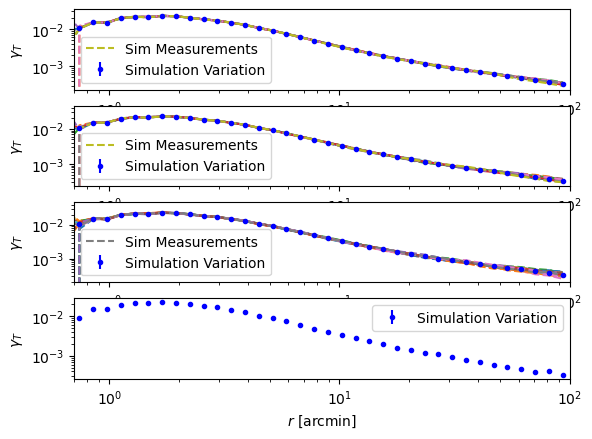

In [25]:
len_sim = len(sim_names)
len_skys=len(nskys)

fig, axs = plt.subplots(len_skys)
for nn, nsky in enumerate(nskys):
    meas_rec=[]
    for ii in range(len_sim):
      #for jj in range(nsky):
      for jj in range(nsky):
          sim_name = sim_names[ii]
          file_name_ii_jj='measurements/datavector_'+sim_name+'_patchN%i_%i.txt'%(nsky, jj)
          if os.path.isfile(file_name_ii_jj):
              dat= np.genfromtxt(file_name_ii_jj)
              axs[nn].plot(dat[:, 0], dat[:, 3], '--', label = 'Sim Measurements')

          if ii == 0 and jj==0:
             meas_rec = dat[:, 3]
          else:
             meas_rec = np.vstack((meas_rec, dat[:, 3]))
    
    x_val = dat[:, 0]
    y_val=np.mean(meas_rec, axis=0)
    y_sim_err=np.std(meas_rec, axis=0)
    axs[nn].errorbar(x_val, y_val, yerr=y_sim_err, fmt='b.', label='Simulation Variation')
    

    handles, labels = axs[nn].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axs[nn].legend(by_label.values(), by_label.keys())
    axs[nn].set_xscale('log')
    axs[nn].set_yscale('log')
    axs[nn].set_xlim(0.7, 100)
    axs[nn].set_xlabel(r'$r$ [arcmin]')
    axs[nn].set_ylabel(r'$\gamma_T$')

    '''
    ## convert angular scale to physical scale
    # Define the cosmology
    cosmo = FlatLambdaCDM(H0=70.0, Om0=0.279) # Example values
    # Define the redshift and angle
    z_cl=0.53 ## need to change depending on the cluster sample
    d_A = cosmo.comoving_distance(z_cl)

    ax2 = axs[nn].twiny()
    mn, mx = axs[nn].get_xlim()
    ax2.set_xlim( (mn* u.arcmin).to(u.radian).value*d_A.value, (mx* u.arcmin).to(u.radian).value*d_A.value)
    ax2.set_xlabel(r'$r$ [Mpc]')
    '''


Plotting the errorbar from covariance and simulation variation

FileNotFoundError: measurements/cov_000_patchN6_0.txt not found.

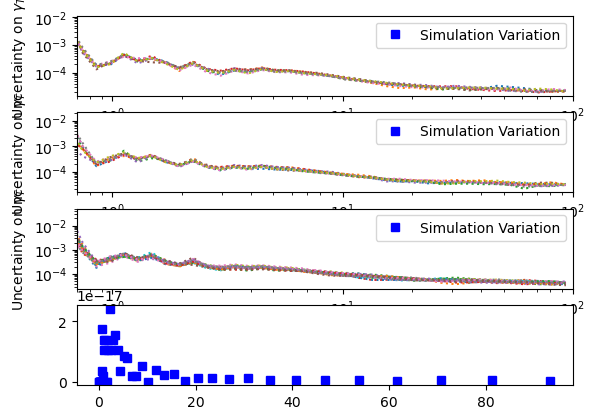

In [27]:
fig, axs = plt.subplots(len_skys)
#cov_jk = np.genfromtxt('data/measurements/cov_065_patchN8_0.txt')
#y_jk_err=np.sqrt(np.diag(cov_jk))
axs[nn].errorbar(x_val, y_sim_err, fmt='bs', label='Simulation Variation')
#ax1.errorbar(x_val, y_jk_err, fmt='ro', label='Jackknife Variation')

for nn, nsky in enumerate(nskys):
    for ii in range(len_sim):
      #for jj in range(nsky):
      for jj in np.arange(0, nsky, 5):
          sim_name = sim_names[ii]
          dat= np.genfromtxt('measurements/cov_'+sim_name+'_patchN%i_%i.txt'%(nsky, jj))
          y_jk_err=np.sqrt(np.diag(dat))
          axs[nn].plot(x_val, y_jk_err, ':', label='JK cov ')

    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axs[nn].legend(by_label.values(), by_label.keys())
    axs[nn].set_xscale('log')
    axs[nn].set_yscale('log')
    axs[nn].set_xlim(0.7, 100)
    axs[nn].set_xlabel(r'$r$ [arcmin]')
    axs[nn].set_ylabel(r'Uncertainty on $\gamma_T$')

'''
## convert angular scale to physical scale
ax2 = ax1.twiny()
mn, mx = ax1.get_xlim()
ax2.set_xlim( (mn* u.arcmin).to(u.radian).value*d_A.value, (mx* u.arcmin).to(u.radian).value*d_A.value)
ax2.set_xlabel(r'$r$ [Mpc]')
'''
